#### IMPORTS

In [1]:
import torch
import numpy as np

from dataloader import MyCustomDataset
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim

import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [2]:
default_dir = os.getcwd()
def default_directory():
    os.chdir(f"{default_dir}")
    print(f"you are back to the default directory: {default_dir}")


In [3]:
default_directory()
os.getcwd()

you are back to the default directory: /home/karansingh/Documents/summer term/ECG_ML/MAIN


'/home/karansingh/Documents/summer term/ECG_ML/MAIN'

In [4]:
os.chdir("ML/Data_cheb")
os.getcwd()

'/home/karansingh/Documents/summer term/ECG_ML/MAIN/ML/Data_cheb'

#### LOAD DATA

In [5]:



data_ST_list = []
for i in range(10):
    cc = np.loadtxt('disease_ST_cheb_'+str(i)+'.txt')
    data_ST_list.append(cc)
    print(f"data st of length {len(cc)} in {i} index loaded")


data_ST_list = np.array(data_ST_list)
images = np.resize(data_ST_list,(3000,10000))

labels=np.zeros(3000)

data_SB_list = []
for i in range(10):
    cc = np.loadtxt('disease_SB_cheb_'+str(i)+'.txt')
    data_SB_list.append(cc)
    print(f"data sb of length {len(cc)} in {i} index loaded")
images = np.concatenate((images,np.resize(data_SB_list,(5000,10000))))
labels=np.concatenate((labels,np.ones(5000)))

data_SR_list = []
for i in range(10):
    cc = np.loadtxt('disease_SR_cheb_'+str(i)+'.txt')
    data_SR_list.append(cc)
    print(f"data sr of length {len(cc)} in {i} index loaded")
images = np.concatenate((images,np.resize(data_SR_list,(5000,10000))))
labels=np.concatenate((labels,np.ones(5000)*2))
                    

data st of length 300 in 0 index loaded
data st of length 300 in 1 index loaded
data st of length 300 in 2 index loaded
data st of length 300 in 3 index loaded
data st of length 300 in 4 index loaded
data st of length 300 in 5 index loaded
data st of length 300 in 6 index loaded
data st of length 300 in 7 index loaded
data st of length 300 in 8 index loaded
data st of length 300 in 9 index loaded
data sb of length 500 in 0 index loaded
data sb of length 500 in 1 index loaded
data sb of length 500 in 2 index loaded
data sb of length 500 in 3 index loaded
data sb of length 500 in 4 index loaded
data sb of length 500 in 5 index loaded
data sb of length 500 in 6 index loaded
data sb of length 500 in 7 index loaded
data sb of length 500 in 8 index loaded
data sb of length 500 in 9 index loaded
data sr of length 500 in 0 index loaded
data sr of length 500 in 1 index loaded
data sr of length 500 in 2 index loaded
data sr of length 500 in 3 index loaded
data sr of length 500 in 4 index loaded


In [6]:



data_ST_list = []
for i in range(10):
    cc = np.loadtxt('disease_ST_cheb_'+str(i)+'.txt')
    data_ST_list.append(cc)
    print(f"data st of length {len(cc)} in {i} index loaded")


data_ST_list = np.array(data_ST_list)
images = np.resize(data_ST_list,(3000,10000))

labels=np.zeros(3000)

data_SB_list = []
for i in range(10):
    cc = np.loadtxt('disease_SB_cheb_'+str(i)+'.txt')
    data_SB_list.append(cc)
    print(f"data sb of length {len(cc)} in {i} index loaded")
images = np.concatenate((images,np.resize(data_SB_list,(5000,10000))))
labels=np.concatenate((labels,np.ones(5000)))

data_SR_list = []
for i in range(10):
    cc = np.loadtxt('disease_SR_cheb_'+str(i)+'.txt')
    data_SR_list.append(cc)
    print(f"data sr of length {len(cc)} in {i} index loaded")
images = np.concatenate((images,np.resize(data_SR_list,(5000,10000))))
labels=np.concatenate((labels,np.ones(5000)*2))
                    

data st of length 300 in 0 index loaded
data st of length 300 in 1 index loaded
data st of length 300 in 2 index loaded
data st of length 300 in 3 index loaded
data st of length 300 in 4 index loaded
data st of length 300 in 5 index loaded
data st of length 300 in 6 index loaded
data st of length 300 in 7 index loaded
data st of length 300 in 8 index loaded
data st of length 300 in 9 index loaded
data sb of length 500 in 0 index loaded
data sb of length 500 in 1 index loaded
data sb of length 500 in 2 index loaded
data sb of length 500 in 3 index loaded
data sb of length 500 in 4 index loaded
data sb of length 500 in 5 index loaded
data sb of length 500 in 6 index loaded
data sb of length 500 in 7 index loaded
data sb of length 500 in 8 index loaded
data sb of length 500 in 9 index loaded
data sr of length 500 in 0 index loaded
data sr of length 500 in 1 index loaded
data sr of length 500 in 2 index loaded
data sr of length 500 in 3 index loaded
data sr of length 500 in 4 index loaded


In [7]:
corrupted_ST = [199, 306, 449, 633, 920, 2132, 2141, 2186, 2256]

corrupted_SB = [1418, 1852, 1898, 2756, 2881, 3007,
                3101, 4091, 4192, 4293, 4376, 4594, 4601, 4720]

corrupted_SR = [149, 192, 213, 340, 385, 441,
                2341, 2451, 2482, 2534, 4903, 4944]

N_ST = 3000
N_SB = 5000

corrupted_global = (
    corrupted_ST
    + [i + N_ST for i in corrupted_SB]          # +3000
    + [i + N_ST + N_SB for i in corrupted_SR]   # +8000
)

corrupted_global = sorted(corrupted_global)
images = np.delete(images, corrupted_global, axis=0)
labels = np.delete(labels, corrupted_global, axis=0)




In [8]:
default_directory()
print(len(images),len(labels))
print(images.shape)
images = images.reshape(images.shape[0],1,100,100)
images.shape



you are back to the default directory: /home/karansingh/Documents/summer term/ECG_ML/MAIN
12965 12965
(12965, 10000)


(12965, 1, 100, 100)

#### CREATE BATCHES

In [9]:
from sklearn.model_selection import train_test_split

X = images        # (12965, 100, 100)
y = labels      # (12965,)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

#split is of 70% train, 15% val, 15% test


In [10]:
import torch
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_dataloader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dataloader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_dataloader  = DataLoader(test_ds, batch_size=32, shuffle=False)

### model

In [11]:
import copy
import torch
import torch.nn as nn
import numpy as np
import os
import time
from datetime import datetime
from IPython.display import clear_output
import importlib, plots
importlib.reload(plots)
from plots import evaluate_all
from seed_utils import set_seed, SEEDS
from model_cnn import SmallCNN

default_directory()

# ── 1. Setup multi-seed tracking ──
all_metrics = []
all_histories = []

log_dir = "EXPERIMENT_2d_cheb_typ1_smallcnn_randomseed"
os.makedirs(log_dir, exist_ok=True)

# Try getting notebook name
try:
    from IPython import get_ipython
    notebook_name = get_ipython().user_ns.get('__vsc_ipynb_file__', None)
    if notebook_name is None:
        import ipynbname
        notebook_name = ipynbname.name()
    notebook_name = os.path.splitext(os.path.basename(notebook_name))[0]
except:
    notebook_name = "main_2d_cheb_typ1"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def log_print(msg, f):
    print(msg)
    f.write(msg + "\n")
    f.flush()

# ── 2. Loop through seeds ──
for seed in SEEDS:
    namkaran = f"cheb_small_cnn_lr1e-3_seed{seed}"
    log_path = os.path.join(log_dir, f"{notebook_name}_{namkaran}.txt")
    
    # Use our seed utility!
    set_seed(seed)

    with open(log_path, "a") as f:
        log_print("\n" + "="*60, f)
        log_print(f"Training Run Started for Seed {seed}: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", f)
        log_print("="*60, f)

        # Initialize model inside loop to reset weights!
        model = SmallCNN().to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2
        )

        def correct(pred, true):
            return (pred == true).sum().item()

        train_losses_list, val_losses_list = [], []
        accuracy_train_list, accuracy_val_list = [], []
        best_acc, wait, best_model = 0, 0, None
        num_epochs, patience = 25, 7
        total_start_time = time.time()

        for epoch in range(num_epochs):
            epoch_start_time = time.time()
            
            # --- Train ---
            model.train()
            run_loss = 0
            c_train = t_train = 0
            train_start_time = time.time()
            for x, y in train_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                run_loss += loss.item()
                c_train += correct(out.argmax(1), y)
                t_train += y.size(0)

            train_time = time.time() - train_start_time
            train_losses_list.append(run_loss / len(train_dataloader))
            accuracy_train_list.append(100 * c_train / t_train)

            # --- Validation ---
            model.eval()
            run_loss = 0
            c_val = t_val = 0
            val_start_time = time.time()
            with torch.no_grad():
                for x, y in val_dataloader:
                    x, y = x.to(device), y.to(device)
                    out = model(x)
                    loss = criterion(out, y)
                    run_loss += loss.item()
                    c_val += correct(out.argmax(1), y)
                    t_val += y.size(0)

            val_time = time.time() - val_start_time
            val_losses_list.append(run_loss / len(val_dataloader))
            accuracy_val_list.append(100 * c_val / t_val)

            # --- LR scheduler ---
            old_lr = optimizer.param_groups[0]["lr"]
            scheduler.step(val_losses_list[-1])
            lr_now = optimizer.param_groups[0]["lr"]
            
            if lr_now != old_lr:
                log_print(f"  >> Learning rate reduced: {old_lr:.6f} -> {lr_now:.6f}", f)

            # --- Early stopping ---
            if accuracy_val_list[-1] > best_acc:
                best_acc, wait = accuracy_val_list[-1], 0
                best_model = copy.deepcopy(model.state_dict())
            else:
                wait += 1
                if wait >= patience:
                    log_print(f"## Early stopping at epoch {epoch + 1} ##", f)
                    break

            epoch_time = time.time() - epoch_start_time
            log_print(
                f"Epoch [{epoch + 1}/{num_epochs}] | "
                f"Train Loss: {train_losses_list[-1]:.4f}, Val Loss: {val_losses_list[-1]:.4f}, "
                f"Train Acc: {accuracy_train_list[-1]:.2f}%, Val Acc: {accuracy_val_list[-1]:.2f}%, "
                f"LR: {lr_now:.6f} | "
                f"Time: {epoch_time:.2f}s", f
            )

        total_training_time = time.time() - total_start_time

        # Restore best weights and save
        model.load_state_dict(best_model)
        torch.save(best_model, os.path.join(log_dir, f"{notebook_name}_{namkaran}.pth"))
        log_print(f"\nBest Validation Accuracy: {best_acc:.2f}%", f)

        log_print("="*60, f)
        log_print(f"Total Training Time: {total_training_time:.2f}s", f)
        
        # ── 3. Evaluate the seed silently and store results ──
        log_print(f"Evaluating best model on test set for seed {seed}...", f)
        results = evaluate_all(
            model, test_dataloader, device,
            plot_confusion_matrix=False,
            plot_pr_micro=False,
            plot_pr_per_class=False,
            plot_roc=False,
            print_report=False
        )
        all_metrics.append(results)
        
        history = {
            "train_acc": accuracy_train_list,
            "val_acc": accuracy_val_list,
            "train_loss": train_losses_list,
            "val_loss": val_losses_list
        }
        all_histories.append(history)

print("\n ALL 5 SEEDS COMPLETED!")


you are back to the default directory: /home/karansingh/Documents/summer term/ECG_ML/MAIN

Training Run Started for Seed 40: 2026-07-02 07:21:22
Epoch [1/25] | Train Loss: 0.3722, Val Loss: 0.2533, Train Acc: 84.47%, Val Acc: 91.26%, LR: 0.001000 | Time: 5.41s
Epoch [2/25] | Train Loss: 0.2015, Val Loss: 0.1160, Train Acc: 92.77%, Val Acc: 95.48%, LR: 0.001000 | Time: 5.17s
Epoch [3/25] | Train Loss: 0.1595, Val Loss: 0.0979, Train Acc: 94.35%, Val Acc: 96.25%, LR: 0.001000 | Time: 5.17s
Epoch [4/25] | Train Loss: 0.1383, Val Loss: 0.0902, Train Acc: 95.12%, Val Acc: 96.66%, LR: 0.001000 | Time: 5.17s
Epoch [5/25] | Train Loss: 0.1270, Val Loss: 0.0746, Train Acc: 95.47%, Val Acc: 97.48%, LR: 0.001000 | Time: 5.17s
Epoch [6/25] | Train Loss: 0.1219, Val Loss: 0.1177, Train Acc: 95.59%, Val Acc: 95.94%, LR: 0.001000 | Time: 5.18s
Epoch [7/25] | Train Loss: 0.1101, Val Loss: 0.0868, Train Acc: 96.21%, Val Acc: 97.17%, LR: 0.001000 | Time: 5.17s
  >> Learning rate reduced: 0.001000 -> 0.0


  MULTI-SEED SUMMARY  (5 seeds: 40–44)
Metric                     Mean        Std
------------------------------------------
  accuracy               98.34% ± 0.13%     
  f1_macro               0.9829 ± 0.0012    
  f1_micro               0.9834 ± 0.0013    
  auc_macro              0.9991 ± 0.0001    
  ap_micro               0.9986 ± 0.0002    
----------------------------------------------------------------------------------------------------
  PER-CLASS CLASSIFICATION REPORT (Mean ± Std)
----------------------------------------------------------------------------------------------------
  Class           Precision            Recall               F1-Score             AUC                  Support
----------------------------------------------------------------------------------------------------
  ST              0.9690 ± 0.0024      0.9898 ± 0.0041      0.9793 ± 0.0013      0.9987 ± 0.0001      449.0
  SB              0.9824 ± 0.0026      0.9987 ± 0.0015      0.9905 ± 0.0012      

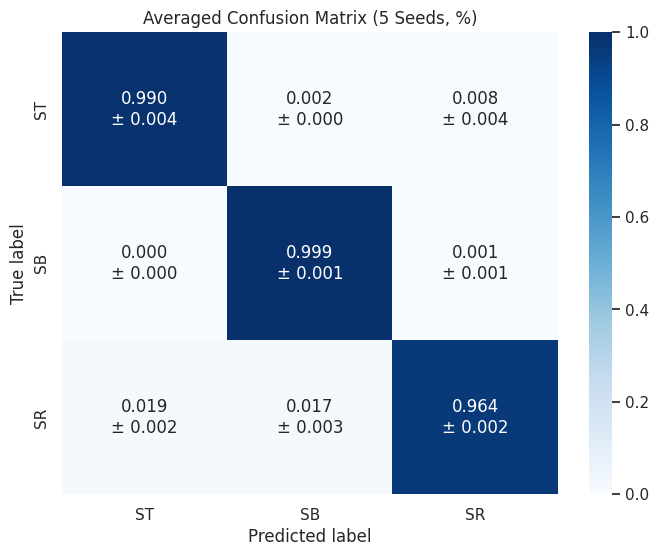

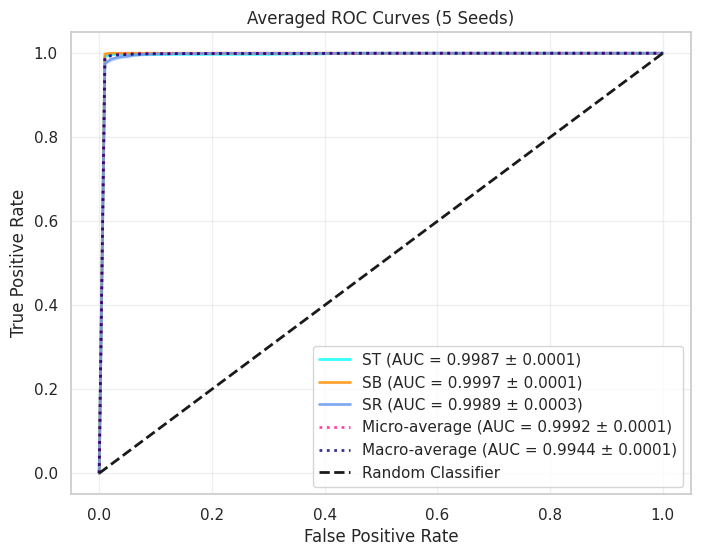

AUC Scores (Mean ± Std):
------------------------------
Class ST: 0.9987 ± 0.0001
Class SB: 0.9997 ± 0.0001
Class SR: 0.9989 ± 0.0003
Micro-average: 0.9992 ± 0.0001
Macro-average: 0.9944 ± 0.0001
------------------------------



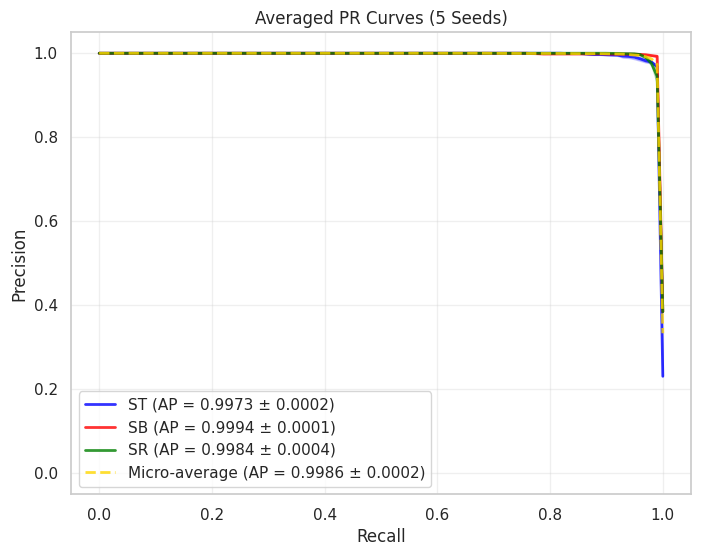

Saved: EXPERIMENT_2d_cheb_typ1_smallcnn_randomseed/cheb_small_cnn_lr1e-3_seed44_val_acc_multiseed.png


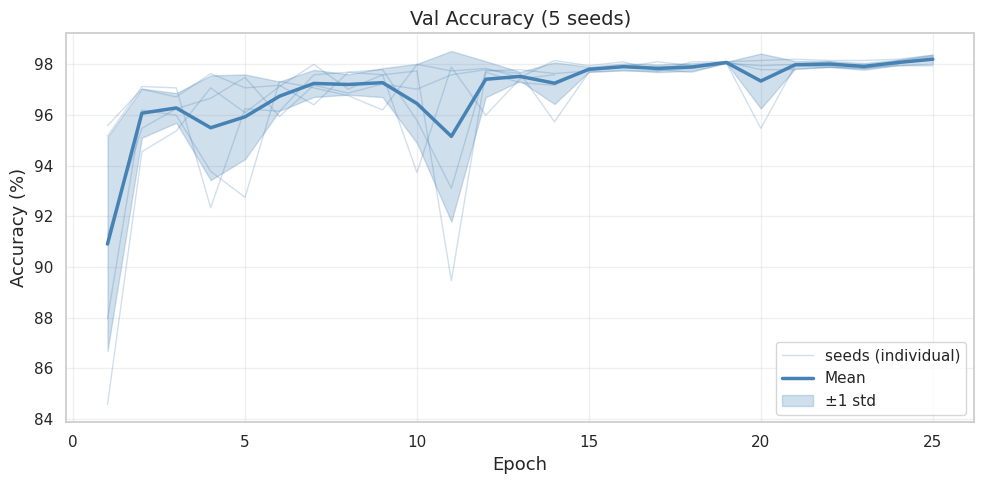

Saved: EXPERIMENT_2d_cheb_typ1_smallcnn_randomseed/cheb_small_cnn_lr1e-3_seed44_val_loss_multiseed.png


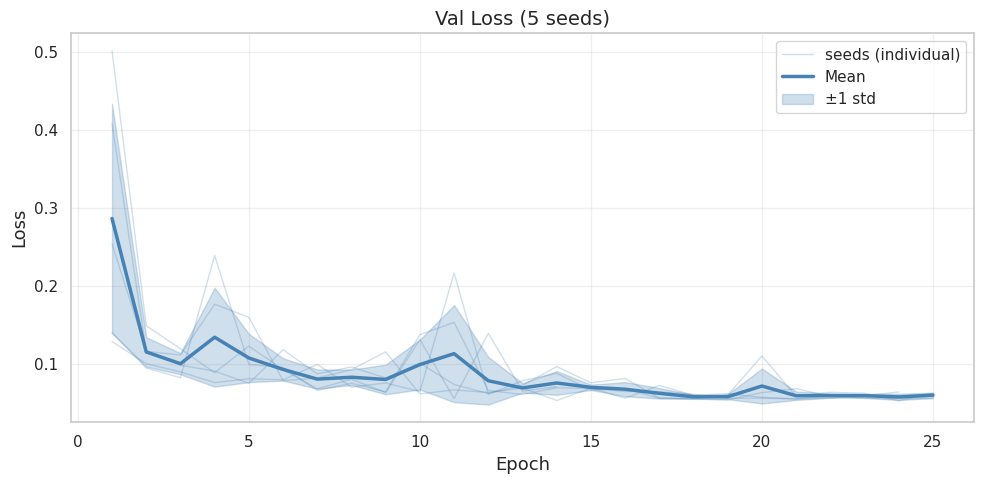

In [12]:
import importlib, plots
importlib.reload(plots)
from plots import plot_learning_curves_multiseed, summarize_seed_results, evaluate_multiseed_plots

# 1. Prints the classification report table and saves the CSV
summarize_seed_results(
    all_metrics,
    save_csv=os.path.join(log_dir, f"{namkaran}_multiseed_summary.csv"),
)

# 2. Plots and saves Averaged CM (Proportions), ROC (+ text AUCs), and PR curves
evaluate_multiseed_plots(
    all_metrics, 
    class_names=["ST", "SB", "SR"],
    save_dir=log_dir,
    namkaran=namkaran
)

# 3. Plots and saves Learning Curves (Accuracy & Loss)
plot_learning_curves_multiseed(
    all_histories, metric="val_acc",
    title=f"Val Accuracy (5 seeds)",
    save_path=os.path.join(log_dir, f"{namkaran}_val_acc_multiseed.png"),
)
plot_learning_curves_multiseed(
    all_histories, metric="val_loss",
    title=f"Val Loss (5 seeds)",
    save_path=os.path.join(log_dir, f"{namkaran}_val_loss_multiseed.png"),
)
